In [1]:
## setup
from pathlib import Path
import sys
ROOT_PATH = (Path.cwd().parents[1]).as_posix()

if ROOT_PATH not in sys.path:
    sys.path.insert(0, ROOT_PATH)
import numpy as np
from src.model.flow_matching_model import GaussianPriorFlowMatching
from src.config import Config
import yaml
from pathlib import Path
import src.dataset as datasets
import torch
import matplotlib.pyplot as plt
from typing import Optional, Sequence, Tuple, Dict, Callable
from src.amplitude_drw_curve_utils.utils import periodogram, red_noise_psd
from typing import Union, Tuple

# Note: "GaussianPriorFlowMatching" refers to the flow-matching base/prior
# distribution p0 (standard Gaussian noise the ODE integrates from) -- this
# is unrelated to the Rayleigh-vs-Uniform amplitude-distribution comparison
# below.
WRAPPER_MAP = {
    "GaussianPriorFlowMatching": GaussianPriorFlowMatching,
}

def load_config(path):
    with open(path, "r") as f:
        yaml_dict = yaml.safe_load(f)
    return Config(**yaml_dict)

def load_experiment(folder_path, checkpoint_name):
    config_path = Path(ROOT_PATH)/ Path(folder_path) / Path("config.yaml")
    checkpoint_path = Path(ROOT_PATH)/ Path(folder_path) / Path(checkpoint_name)
    config = load_config(config_path)
    config.data.dataset_folder = str(Path(ROOT_PATH) / Path(config.data.dataset_folder))
    data_module = getattr(datasets, config.data.data_class)(config.data)
    wrapper = WRAPPER_MAP[config.lightning_wrapper](config)
    checkpoint = torch.load(checkpoint_path,map_location="cpu", weights_only="False")
    wrapper.load_state_dict(checkpoint["state_dict"], strict=True)
    return wrapper, data_module


/nfs/scistore20/bronsgrp/nsellam/miniforge3/envs/ml/lib/python3.11/site-packages/transformers/utils/generic.py:441: UserWarning: torch.utils._pytree._register_pytree_node is deprecated. Please use torch.utils._pytree.register_pytree_node instead.
  _torch_pytree._register_pytree_node(


In [2]:
## load models
rayleigh_folder_path = "outputs/gaussian prior - rayleigh drw"
rayleigh_checkpoint_name = "step=step=160500-v1.ckpt"

uniform_folder_path = "outputs/gaussian prior - uniform drw even bigger model longer train no time domain"
uniform_checkpoint_name = "step=step=100000.ckpt"

rayleigh_model_wrapper, data_module = load_experiment(rayleigh_folder_path, rayleigh_checkpoint_name)
uniform_model_wrapper, data_module = load_experiment(uniform_folder_path, uniform_checkpoint_name)
rayleigh_model_wrapper.to("cuda")
uniform_model_wrapper.to("cuda")
pass

In [3]:
## draw samples from the model and dataset
num_curves = 3000
rayleigh_model_samples = rayleigh_model_wrapper.sample(num_curves)
uniform_model_samples = uniform_model_wrapper.sample(num_curves)
dataset_samples = data_module.get_reference_curves(num_curves)


In [10]:
def render_avg_psd_vs_target(
    signals: Union[np.ndarray, Sequence[Tuple[np.ndarray, str]]],
    *,
    target_psd_fn: Optional[Callable[[np.ndarray], np.ndarray]] = None,
    decay: float = 0.95,
    sigma: float = 0.08,
    title: Optional[str] = None,
    loglog: bool = True,
    skip_lasts: int = 3,
    fontsize: float = 20,
) -> Tuple[plt.Figure, Dict[str, float]]:

    if isinstance(signals, np.ndarray):
        signal_sets = [(signals, "Average PSD")]
    else:
        signal_sets = list(signals)

    if len(signal_sets) == 0:
        raise ValueError("signals must contain at least one signal array")

    for sig, name in signal_sets:
        assert sig.ndim == 2, f"signals for {name!r} must be [N, T]"

    first_signals = signal_sets[0][0]

    f_ref, _ = periodogram(first_signals[0])

    target_psd = (
        red_noise_psd(f_ref, decay=decay, sigma=sigma)
        if target_psd_fn is None
        else target_psd_fn(f_ref)
    )

    num_plots = len(signal_sets)

    fig, axes = plt.subplots(
        2,
        num_plots,
        figsize=(6.5 * num_plots, 10),
        sharey="row",
        gridspec_kw={"height_ratios": [2, 1]},
    )

    if num_plots == 1:
        axes = axes.reshape(2, 1)

    sl = slice(1, -skip_lasts if skip_lasts > 0 else None)

    # Cleaner, more distinct colors
    colors = [
        "#1f77b4",  # blue
        "#d62728",  # red
        "#2ca02c",  # green
        "#9467bd",  # purple
        "#ff7f0e",  # orange
        "#17becf",  # cyan
    ]

    metrics = {}

    for k, (sig, name) in enumerate(signal_sets):

        ax_top = axes[0, k] if num_plots > 1 else axes[0]
        ax_bottom = axes[1, k] if num_plots > 1 else axes[1]

        N, _ = sig.shape

        P_all = np.empty(
            (N, f_ref.shape[0]),
            dtype=np.float64,
        )

        for i in range(N):

            f, P = periodogram(sig[i])

            if (
                f.shape != f_ref.shape
                or not np.allclose(f, f_ref)
            ):
                raise ValueError(
                    f"periodogram returned different "
                    f"frequency grid for {name!r}"
                )

            P_all[i] = P

        avg_psd = P_all.mean(axis=0)

        mask = f_ref > 0

        num = np.linalg.norm(
            avg_psd[mask] - target_psd[mask]
        )

        den = (
            np.linalg.norm(target_psd[mask])
            + 1e-12
        )

        metrics[f"{name}_rel_L2"] = float(num / den)

        # TOP PLOT: PSD curves
        plot_fn = ax_top.loglog if loglog else ax_top.plot

        # Main PSD curve
        plot_fn(
            f_ref[sl],
            avg_psd[sl],
            lw=3.0,
            color=colors[k % len(colors)],
            label=name,
            zorder=2,
        )

        # Target PSD on top
        plot_fn(
            f_ref[sl],
            target_psd[sl],
            linestyle="--",
            lw=3.5,
            color="0.65",
            label="Target PSD",
            zorder=10,
        )

        ax_top.set_xlabel(
            "Frequency",
            fontsize=fontsize,
        )

        if k == 0:
            ax_top.set_ylabel(
                "PSD",
                fontsize=fontsize,
            )

        ax_top.tick_params(
            axis="both",
            labelsize=fontsize,
        )

        ax_top.grid(
            True,
            which="both",
            ls=":",
            color="0.8",
        )

        ax_top.legend(
            fontsize=fontsize * 0.75,
            frameon=False,
        )

        ax_top.set_title(
            name,
            fontsize=fontsize,
        )

        # BOTTOM PLOT: Absolute relative error |avg_psd - target_psd| / target_psd
        relative_error = np.abs((avg_psd - target_psd) / (target_psd + 1e-12))
        
        ax_bottom.loglog(
            f_ref[sl],
            relative_error[sl],
            lw=2.5,
            color=colors[k % len(colors)],
            zorder=2,
        )

        ax_bottom.set_xlabel(
            "Frequency",
            fontsize=fontsize,
        )

        if k == 0:
            ax_bottom.set_ylabel(
                "Absolute Relative Error",
                fontsize=fontsize,
            )

        ax_bottom.tick_params(
            axis="both",
            labelsize=fontsize,
        )

        ax_bottom.grid(
            True,
            which="both",
            ls=":",
            color="0.8",
        )

        ax_bottom.set_title(
            "|avg-target|/target",
            fontsize=fontsize * 0.85,
        )

    if title:
        fig.suptitle(
            title,
            fontsize=fontsize,
        )

    fig.tight_layout()
    return fig, metrics

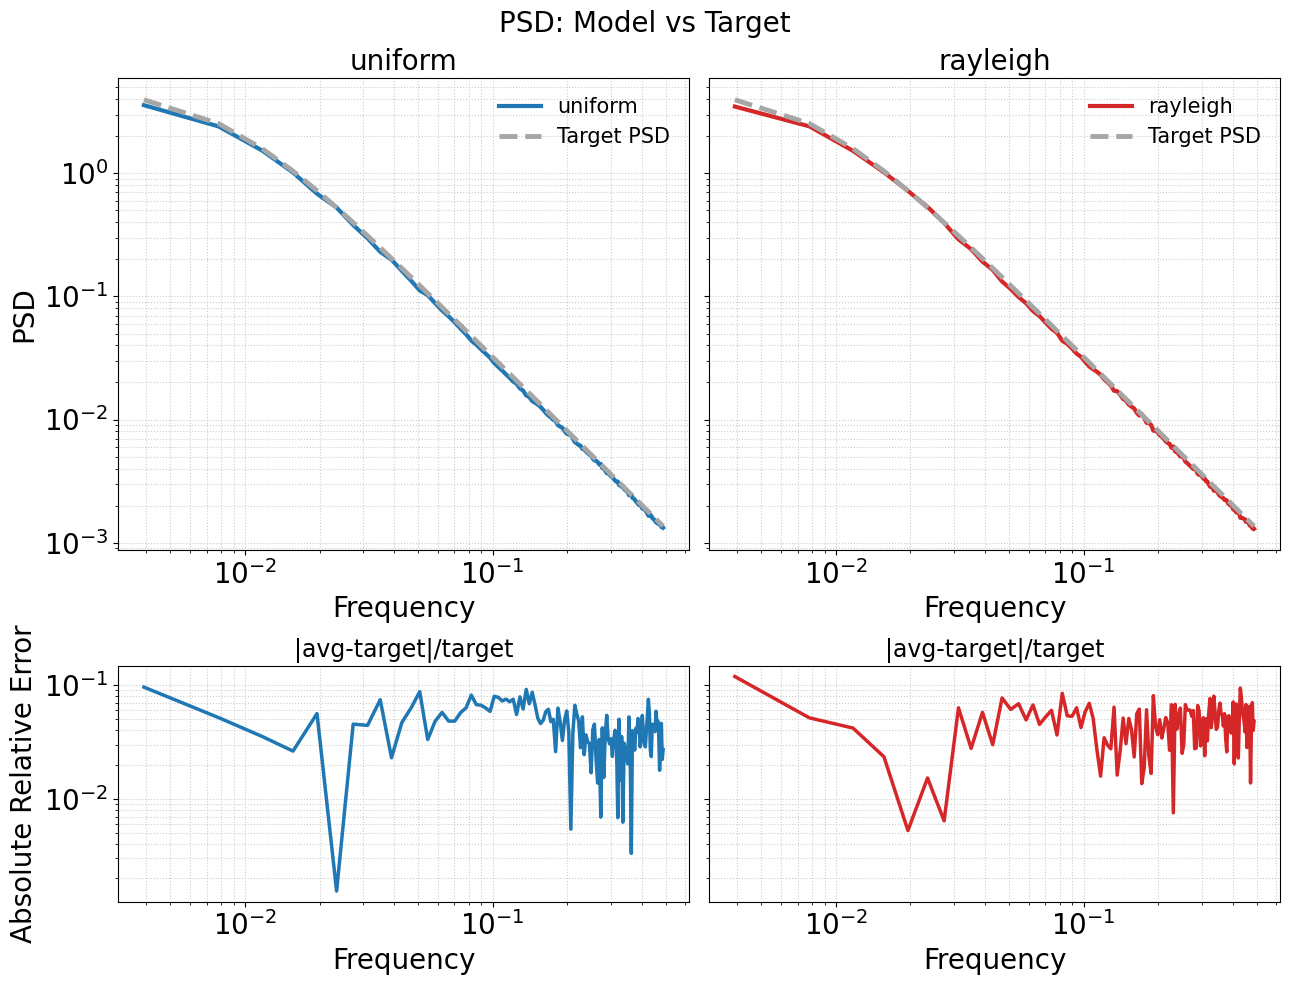

In [11]:
## render
render_avg_psd_vs_target(
    signals=[(uniform_model_samples.cpu().numpy().squeeze(), "uniform"), (rayleigh_model_samples.cpu().numpy().squeeze(), "rayleigh")],
    title="PSD: Model vs Target",
    # cmap="viridis"
    )
# plt.tight_layout(rect=[0, 0, 1, 0.95])

plt.savefig(
    "psd_model_vs_target.png",
    dpi=500,
    # bbox_inches="tight",
    # pad_inches=0.2,
)
